# Case 1 -- Appendix: M02-vs-M13 Segment Test (Poplar Side Branch)

**Dissertation Chapter 6, Appendix (Appendices/Appendix.tex) (p. 150):**

> Pearson correlation coefficients were calculated for each successive pair of temporally
> aligned TACs to detect shape changes indicative of exchange processes (Figure
> fig:poplar_exchange_combined a). [...] Based on this, the segment between ROIs 1 and 2 was
> tested with model M13 and compared against model M02. The M02 model failed to represent the
> shape change of the TAC between ROI 1 and ROI 2 (Figure fig:exchange_m02first). Consequently,
> model M13 was selected for the final model configuration in this segment.

- Data: `Poplar_02_L1_M3_second_Branch_velocity_change.csv` (5 ROIs along the side branch).
- Model: 5 MCT units in series (this test configuration), 17 parameters total.
- Reproduces: `Figures/exchange_M02first.pdf`.
- Companion notebooks: preliminary analysis
  `case1_preliminary_hmax_pearson_poplar_side_branch.ipynb`, the Changing Dispersion Case
  `case1_changing_dispersion_poplar_side_branch.ipynb`, the Changing Cross-Sectional-Areas Case
  `case1_changing_area_poplar_side_branch.ipynb`.

## Setup

In [14]:
import os
os.makedirs("output/figures", exist_ok=True)


## Imports

In [15]:
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr

from IPython import display

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_live_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
df = pd.read_csv('data/case1_poplar_side_branch_velocity_change.csv', index_col=0)
data = df.to_numpy(dtype=float)
xi = [float(c) for c in df.columns]

t = df.index.to_numpy(dtype=float)[2:]

In [17]:
orig_exp_data = data[2:,0:5]
exp_data = data[2:,0:5]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))
exp_data = exp_data/np.max(exp_data)

## Process model

In [18]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct2_e12 = x[2]
    p_mct3_e12 = x[3]
    p_mct4_e12 = x[4]
    p_mct5_e12 = x[5]
    p_mct1_disp = x[6]
    p_mct2_disp = x[7]
    p_mct3_disp = x[8]
    p_mct4_disp = x[9]
    p_mct5_disp = x[10]
    p_total_porosity = x[11]
    p_col_dispersion = x[12]
    p_col_len = x[13]
    p_t0 = x[14]
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    mct4 = MCT(component_system, nchannel=2, name='mct4')
    mct5 = MCT(component_system, nchannel=2, name='mct5')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20
    mct4.discretization.ncol = 20
    mct5.discretization.ncol = 20

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    mct4.bulk_reaction_model = reaction_system
    mct5.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(mct4)
    mct_flow_sheet.add_unit(mct5)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = p_total_porosity
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, mct4, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct4, mct5, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct5, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    mct4.length =  xi[4]/1000-xi[3]/1000
    mct5.length =  xi[-1]/1000-xi[4]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    mct4.channel_cross_section_areas = [1,1] 
    mct5.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct1_disp
    mct2.axial_dispersion = p_mct2_disp
    mct3.axial_dispersion = p_mct3_disp
    mct4.axial_dispersion = p_mct4_disp
    mct5.axial_dispersion = p_mct5_disp
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1
    mct4.solution_recorder.write_solution_bulk = 1
    mct5.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct4.exchange_matrix =np.array([
                                    [[0.0], [p_mct4_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct5.exchange_matrix =np.array([
                                    [[0.0], [p_mct5_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [19]:
param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),
    'mct1_e12': (1e-10, 20),
    'mct2_e12': (1e-10, 20),
    'mct3_e12': (1e-10, 20),
    'mct4_e12': (1e-10, 20),
    'mct5_e12': (1e-10, 20),
    'disp1': (1e-16, 1e-3),
    'disp2': (1e-17, 1e-2),
    'disp3': (1e-10, 1e-2),
    'disp4': (1e-10, 1e-2),
    'disp5': (1e-10, 1e-2),
    'total_porosity': (0.1, 0.99),
    'col_dispersion': (1e-07, 1e-06),
    'col_len': (0.01, 0.3),
    't0': (0.1, 2),
}

problem = OptimizationProblem("case1_appendix")
for name, (lb, ub) in param_bounds.items():
    problem.add_variable(name, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")


## Objective function

In [20]:
def _forward_model(x):
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0]*60, t[-1]*60+5*60, 5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1]
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = [0.0]

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T

    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new=eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new=eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new=eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T

    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new=eval_location5)
    calc_data_mct5 = np.atleast_2d(np.sum(cb_mct5, axis=2).squeeze()).T

    calc_data = np.hstack((calc_data_mct1, calc_data_mct2, calc_data_mct3, calc_data_mct4, calc_data_mct5))
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    calc_data, time_new = _forward_model(x)
    nmsre = np.mean((calc_data.ravel() - exp_data.ravel()) ** 2) / np.mean(exp_data.ravel() ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    calc_data, _ = _forward_model(x)
    return (calc_data - exp_data).ravel() / np.sqrt(np.mean(exp_data ** 2))

problem.add_objective(objective, n_objectives=1)

In [21]:
_obj_history = []
_live_plot_active = False

In [22]:
simulator = Cadet()    

## Optimization

In [23]:
x_best_fit_published = np.array([5.61947399e-05, 1.22196816e-03,
       8.00878318e-04, 9.87130324e-04, 9.30968467e-04, 3.75992691e-03,
       5.09942807e-10, 3.16227548e-16, 1.06878965e-06, 2.60152354e-06,
       2.35973612e-06, 6.27727280e-01, 7.42028671e-07, 1.88143053e-01,
       1.78007673e+00])

def run_optimization(optimize=False, live_plot=False, method="nm+tc", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr (default)
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x_best_fit = result_tc.x[0]
    else:
        x_best_fit = x0

    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

## Final fit figure

In [24]:
def plot_for_publication(x):
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,60*5)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]
    

    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = [0.0]

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T
    
    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new = eval_location5)
    calc_data_mct5 = np.atleast_2d(np.sum(cb_mct5, axis=2).squeeze()).T

    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4, calc_data_mct5))
    calc_data = calc_data/np.max(calc_data)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.plot(t,calc_data[:,0:1], label="ROI 1", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(t,calc_data[:,1:2], label="ROI 2", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(t,calc_data[:,2:3], label="ROI 3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    plt.plot(t,calc_data[:,3:4], label="ROI 4", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], linewidth=1.5)
    plt.plot(t,calc_data[:,4:5], label="ROI 5", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:1],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,1:2],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,2:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)
    plt.plot(t,exp_data[:,3:4],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], markersize=8)
    plt.plot(t,exp_data[:,4:5],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates
    

    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(),fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    plt.savefig("output/figures/exchange_M02first.pdf", format="pdf")  

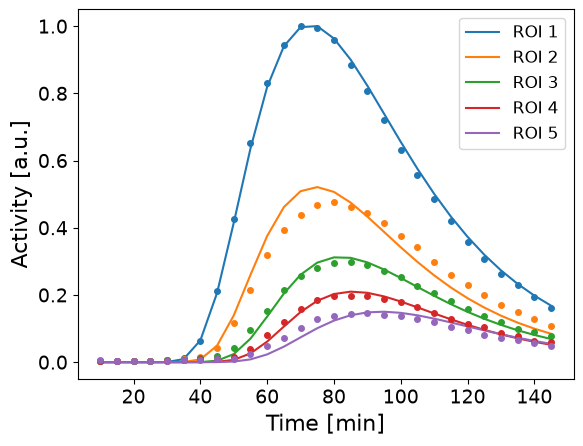

In [25]:
plot_for_publication(x_best_fit)

## Parameter uncertainties

In [26]:
param_uncertainties = compute_parameter_uncertainties(residuals, x_best_fit)
rel_param_uncertainties = param_uncertainties / np.abs(x_best_fit)

for i, uncertainty in enumerate(rel_param_uncertainties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

Parameter 0: ±2.9824492155729536%
Parameter 1: ±8.656812089443257%
Parameter 2: ±24.7039021787931%
Parameter 3: ±27.800880057458173%
Parameter 4: ±38.5851526677863%
Parameter 5: ±123.94504046251404%
Parameter 6: ±1318.937690738756%
Parameter 7: ±1189295699.9566665%
Parameter 8: ±124.42381283031713%
Parameter 9: ±378.2888706815421%
Parameter 10: ±91.7386232610919%
Parameter 11: ±0.05092887820132182%
Parameter 12: ±3.053184998929129%
Parameter 13: ±0.5660972560149766%
Parameter 14: ±0.003701576753235195%
